# Visiual Feature Extraction


In [1]:
# tek videoluk feature pipeline - feature extraction

"""

Tek bir test videosu üzerinden uçtan uca bir görsel feature excraction pipeline' yazdık.
bu pipeline sayesinde gerçek verileri aldığımız da - örneğin 50000 video -
videoları işleyip her biri için feature excraction yapmış olacağız.

test_video.mp4 (yt-dlp, ~10 MB)
   → FFmpeg, fps=1 → 170 adet JPG frame
   → InceptionV3 (frozen, ImageNet pretrained) → [170, 2048] feature matrisi
   → HDF5 dosyası: trt_features.h5 → video_test/visual


1) Frozen encoder mantığını burada kullandık.
TripleSumm'ın eğitim kodu videoyu hiç görmez; hazır feature matrisleri okur.
Encoder'lar (InceptionV3, AST, BERTurk) eğitim boyunca değişmediği için feature'ları bir kez çıkarıp diske yazmak yeterli.
Bu, eğitimi 10–100x hızlandırır ve T4 GPU'da sadece 2.7M parametrelik fusion modelinin çalışmasını sağlar.

2) fps = 1 yaptık.
Ardışık kareler neredeyse özdeş; saniyede 1 frame hem N'i küçültür hem de f
rame indeksi = saniye eşitliğini kurar.
Bu eşitlik ileride A2Summ segment mask'inde (altyazı [t_s, t_e] → frame indeksi) doğrudan kullanılacak.

3) HDF5: HDF5 kısmi okuma sağlar (tüm dosya RAM'e gelmeden dilim okunur),
tek dosyada hiyerarşi tutar (video_0001/visual, /audio, /text) ve
TripleSumm/A2Summ repo'larının beklediği format budur.

⚠️ 2048 vs 1024 uyumsuzluğu:
torchvision InceptionV3'ün (asagıda yazdığımız model)GAP çıktısı 2048-d,
ama TripleSumm notları 1024-d diyor (visual_proj = nn.Linear(1024, 128)).
bunu ileride projection yapmamaız gerekebilir.

"""

"\n\nTek bir test videosu üzerinden uçtan uca bir görsel feature excraction pipeline' yazdık.\nbu pipeline sayesinde gerçek verileri aldığımız da - örneğin 50000 video -\nvideoları işleyip her biri için feature excraction yapmış olacağız.\n\ntest_video.mp4 (yt-dlp, ~10 MB)\n   → FFmpeg, fps=1 → 170 adet JPG frame\n   → InceptionV3 (frozen, ImageNet pretrained) → [170, 2048] feature matrisi\n   → HDF5 dosyası: trt_features.h5 → video_test/visual\n\n\n1) Frozen encoder mantığını burada kullandık.\nTripleSumm'ın eğitim kodu videoyu hiç görmez; hazır feature matrisleri okur.\nEncoder'lar (InceptionV3, AST, BERTurk) eğitim boyunca değişmediği için feature'ları bir kez çıkarıp diske yazmak yeterli.\nBu, eğitimi 10–100x hızlandırır ve T4 GPU'da sadece 2.7M parametrelik fusion modelinin çalışmasını sağlar.\n\n2) fps = 1 yaptık.\nArdışık kareler neredeyse özdeş; saniyede 1 frame hem N'i küçültür hem de f\nrame indeksi = saniye eşitliğini kurar.\nBu eşitlik ileride A2Summ segment mask'inde (alty

In [2]:
!pip install yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.5 MB/s eta 0:00:00


In [3]:
!yt-dlp -f "mp4" -o "test_video.mp4" https://www.youtube.com/watch?v=ZZHDNnBSNhU

# -f: format
# -o: output_name

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://www.youtube.com/watch?v=ZZHDNnBSNhU
[youtube] ZZHDNnBSNhU: Downloading webpage
[youtube] ZZHDNnBSNhU: Downloading android vr player API JSON
[info] ZZHDNnBSNhU: Downloading 1 format(s): 18
[download] Destination: test_video.mp4
[download] 100% of    9.62MiB in 00:00:00 at 10.83MiB/s


In [4]:
import os
# ffmpeg

"""
FFmpeg, video dosyasını açıp kare kare okuyabilen standart araçtır.
Bizim kullanacağımız özellik -vf fps=1 filtresi:
"videonun orijinal fps'i ne olursa olsun, bana saniyede 1 kare ver."
FFmpeg bunu yaparken kareleri diskteki bir klasöre görüntü dosyası olarak yazar.
"""
os.makedirs("frames", exist_ok=True) # frames dosyası var mı yok mu
!ffmpeg -version
!ffmpeg -i test_video.mp4 -vf fps=1 frames/frame_%04d.jpg

# -i: input
# -vf: video filter

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-l

In [5]:
# Inception V3
import torchvision # PyTorch'un bilgisayarlı görü (Computer Vision) kütüphanesidir.
from torchvision.models import inception_v3, Inception_V3_Weights

model = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1) # ağ mimarisi olusturulur
# ImageNet-1K üzerinde eğitilmiş, 1. sürüm ağırlıklar.
# ImageNet yaklaşık 1.2 milyon resim, 1000 sınıf içeren dev bir veri kümesidir.

import torch.nn as nn

model.eval(); # modeli değerlendirme (evaluation) moduna geçirir. eğitim modu da vardır.
model.fc = nn.Identity() # Inception'ın en son katmanıdır. böylece resmi sayısal olarak temsil ederiz.
model.to("cuda")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:02<00:00, 46.2MB/s] 


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [6]:
# 1. Transform zinciri
import torch
from torchvision import transforms
import PIL

frame = PIL.Image.open("frames/frame_0001.jpg") # diskteki resmi okuma, açma
# bu bir PIL nesnesi, tensor vs değil.

transform = transforms.Compose([
    transforms.Resize((299, 299)), # Inception V3'ün giriş boyutu sabittir. 299 x 299
    transforms.ToTensor(), # PIL nesnesini tensora cevirir. 3 * 299 * 299 -> channel, height, width
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # normalize işlemi
                         std=[0.229, 0.224, 0.225])  # ImageNet veri setinin ortalama ve standart sapmasıdır.
])
# burda bir transformer yaratıyoruz.
# bu transformer sunları yapacak:
# resim(input) -> Resize -> ToTensor -> Normalize -> Out

x = transform(frame) # transformer uygula.
print(x.shape) # torch.Size([3, 299, 299]) beklenildiği gibi 3 * 299 * 299 -> channel, height, width

x = torch.unsqueeze(x, 0) # 0 demek ilk eksene yeni boyut ekle
print(x.shape) # torch.Size([1, 3, 299, 299])

# üstteki resmi batch yaparız. çünkü CNN'ler tek resim değil, birden fazla aynı resmi işler.
# beklediği şekil: batch -> channel -> height, width


with torch.no_grad(): # Gradient hesaplama.
  out = model(x.to("cuda"))
print(out.shape) # torch.Size([1, 2048])

# normalde pytorch backpropagation'da kullanmak üzere her işlemi bellekte saklar.
# conv, relu, v.s.
# fakat bu sadece tahmin olduğu için (egitim yok), gradient tutulmaz.
# boylece daha az RAM, DAHA az GPU, daha hızlı olur.
# # torch.Size([1, 2048]) ise 1 batch, 2048 ise her resim için cıkarılan özellik - feature vektorunun uzunlugudur

torch.Size([3, 299, 299])
torch.Size([1, 3, 299, 299])
torch.Size([1, 2048])


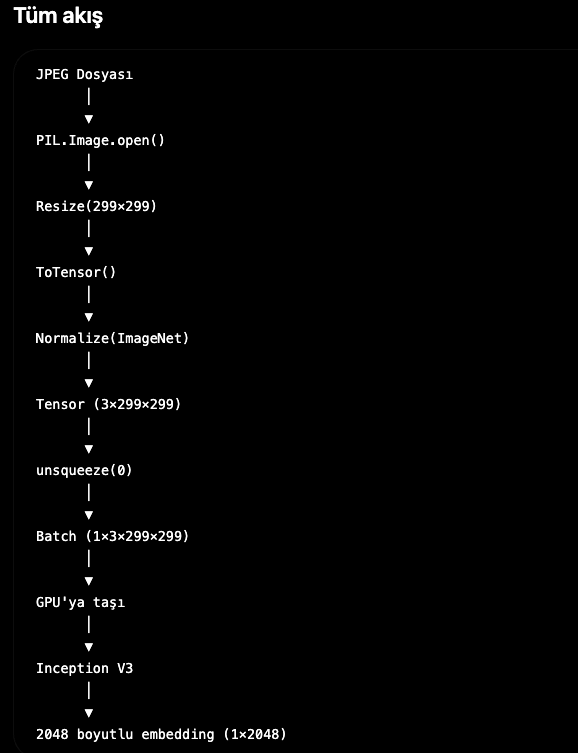

In [7]:
# frames klasöründeki görüntüleri tek tek modele verip bunun yerine 32'li grup
# (batch) halinde işleyip her görüntü için 2048 boyutlu özellik - feature -
# vektörü üreteceğiz.

import os

all_features = [] # Bu  modelin ürettiği çıktıları saklıyor.
batch_frames = [] #  Bu liste henüz modele verilmemiş görüntüleri tutuyor.

for i in sorted(os.listdir("frames")):
  if i.endswith(".jpg"):
    frame = PIL.Image.open(os.path.join("frames", i))
    x = transform(frame) # transform uygula
    batch_frames.append(x) # modelin cıktısını üstteki listeye ekle.

    if len(batch_frames) == 32: # eğer bir batch dolarsa - 32 tane olursa -
      xx = torch.stack(batch_frames) # bu 32 tane resmi tek tensor haline getirir.
      # normalde tensor(3,299,299), tensor(3,299,299), tensor(3,299,299) .......
      # stackten sonra (32,3,299,299) haline getirir.

      with torch.no_grad():
        out = model(xx.to("cuda")) # modeli calıstırır.

      # modelin cıktısı (32,2048) olarak gecer. bir döngü de.
      all_features.append(out.cpu())
      batch_frames = []


if len(batch_frames) > 0: # 170 32'ye tam bölünmediği için kalanları da direkt modele sokup ekleriz.
  xx = torch.stack(batch_frames)
  with torch.no_grad():
    out = model(xx.to("cuda"))
  all_features.append(out.cpu())

features = torch.cat(all_features)

print(features.shape)


torch.Size([170, 2048])


In [8]:
# 2048 boyutlu görüntü feature vektörlerini diske düzenli ve verimli bir şekilde kaydedeceğiz.
# Çünkü gerçek projelerde binlerce hatta milyonlarca frame'in özelliklerini RAM'de tutmak mümkün değildir.


# h5py, çok büyük miktarda sayısal veriyi depolamak ve işlemek için kullanılan bir Python kütüphanesidir
import h5py
# f = h5py.h5py.File("trt_features.h5", "w")
# w = yeni yoksa dosya olusturur varsa siler yeniden olusturur.
# r olsa idi sadece okurdu, a var olanı eklerdi.

# with ile acmamızın sebebi with'ten cıkında f.close otomatik olarak yapar.
# Yani dosya güvenli şekilde kapatılır.

with h5py.File("trt_feature.h5", "w") as f:
  grp = f.create_group("video_test") # video_test diye bir dosya olusturur.
  # Gerçek dataset'te her video kendi grubunu alacak: video_0001, video_0002...
  # Böylece bir videonun üç modalitesi aynı çatı altında toplanır.
  # yani gerçek projede binlerce video olacak. Her videonun kendi verisi olacak.

  grp.create_dataset("visual", data=features.numpy())
  # h5py, PyTorch'tan habersizdir; NumPy dizisi bekler.
  # visual ismi bilerek verildi. daha sonra audio ve text gelecek.
"""
  trt_features.h5
└── video_test/
    ├── visual  [170, 2048]
    ├── audio   [170, 768]    ← AST'den gelecek
    └── text    [M, 768]      ← BERTurk'ten gelecek
"""


# actıgımız dosyayı tekrar okuyoruz emin olmak için
with h5py.File("trt_feature.h5", "r") as f:
  print(f.keys())
  print(f["video_test/visual"].shape)
  print(f["video_test/visual"][0][:5])

<KeysViewHDF5 ['video_test']>
(170, 2048)
[0.2633499  0.18492334 0.0994892  0.04953383 0.38081792]


# Audio Feature Extraction

In [9]:
"""

Standart konuşma kaydında saniyede 16.000 ölçüm yapılır (16 kHz sampling rate).
Yani 3 dakikalık videonun sesi = yaklaşık 2.9 milyon sayıdan oluşan tek boyutlu bir dizi.
Buna waveform denir. Waveform'daki tek bir sayının anlamı yok denecek kadar azdır.
"0.37" değeri sana hiçbir şey söylemez
— konuşma mı, müzik mi, siren mi, bilemezsin.
Bilgi, sayıların salınım hızında gizli:
- Saniyede 100 kez salınıyorsa → kalın bir ses (erkek sesi temel frekansı ~100 Hz)
- Saniyede 1000 kez salınıyorsa → ince bir ses
- Birçok hız aynı anda üst üste binmişse → karmaşık ses (konuşma, müzik hep böyledir).
"frekans" tam olarak bu: saniyedeki salınım sayısı (Hz).

Fourier dönüşümü:
matematikte her karmaşık dalga, farklı frekanslarda basit sinüs dalgalarının toplamı olarak yazılabilir.
Fourier dönüşümü, bu ayrıştırmayı yapan işlemdir.
karışık waveform'u alır, "içinde 100 Hz'den şu kadar, 500 Hz'den bu kadar, 2000 Hz'den şu kadar var"
diye bir frekans reçetesi çıkarır.
Ama tek başına Fourier'in bir eksiği var:
tüm kaydın reçetesini tek seferde çıkarır, zamanı ezer.

Çözüm: pencereleme → spektrogram: kaydı tek seferde analiz etme, küçük zaman pencerelerine böl
(tipik olarak 25 milisaniyelik dilimler, 10 ms'de bir kaydırarak),
her pencereye ayrı Fourier uygula. Böylece her 10 ms için bir frekans reçetesi elde edersin.

Bu reçeteleri yan yana dizersen bir matris oluşur:
- Sütunlar = zaman (her sütun bir 10 ms'lik an)
- Satırlar = frekans (alt satırlar kalın, üst satırlar ince sesler)
- Hücre değeri = o anda o frekansın gücü (görselleştirmede parlaklık).

İşte spektrogram budur. Ses, tek boyutlu bir diziden iki boyutlu bir "zaman-frekans fotoğrafına" dönüştü.


Geldiğimiz nokta: 2.9 milyon sayılık anlamsız dizi → [128, zaman] boyutlu, desenleri anlamlı bir "fotoğraf".
Fotoğraf olduğu anda görüntü işlemenin bütün cephanesi kullanılabilir hale gelir.
AST'nin yaptığı tam bu: spektrogramı ViT gibi 16×16 patch'lere böler,
her patch bir token olur, transformer bu token dizisi üzerinde attention çalıştırır.
AudioSet'in 2 milyon klibinde eğitildiği için
"konuşma deseni", "müzik deseni", "kalabalık uğultusu deseni" gibi kavramları patch düzeyinde tanır.

AST, AudioSet'te 16 kHz'lik seslerle eğitildi;
farklı sampling rate verirsen spektrogramdaki desenler modelin öğrendiklerinden kayar
"""

'\n\nStandart konuşma kaydında saniyede 16.000 ölçüm yapılır (16 kHz sampling rate).\nYani 3 dakikalık videonun sesi = yaklaşık 2.9 milyon sayıdan oluşan tek boyutlu bir dizi.\nBuna waveform denir. Waveform\'daki tek bir sayının anlamı yok denecek kadar azdır.\n"0.37" değeri sana hiçbir şey söylemez\n— konuşma mı, müzik mi, siren mi, bilemezsin.\nBilgi, sayıların salınım hızında gizli:\n- Saniyede 100 kez salınıyorsa → kalın bir ses (erkek sesi temel frekansı ~100 Hz)\n- Saniyede 1000 kez salınıyorsa → ince bir ses\n- Birçok hız aynı anda üst üste binmişse → karmaşık ses (konuşma, müzik hep böyledir).\n"frekans" tam olarak bu: saniyedeki salınım sayısı (Hz).\n\nFourier dönüşümü:\nmatematikte her karmaşık dalga, farklı frekanslarda basit sinüs dalgalarının toplamı olarak yazılabilir.\nFourier dönüşümü, bu ayrıştırmayı yapan işlemdir.\nkarışık waveform\'u alır, "içinde 100 Hz\'den şu kadar, 500 Hz\'den bu kadar, 2000 Hz\'den şu kadar var"\ndiye bir frekans reçetesi çıkarır.\nAma tek başı

In [10]:
!ffmpeg -i test_video.mp4 -vn -ac 1 -ar 16000 audio.wav

# videodan yalnızca sesi çıkarıp,
# onu tek kanallı ve 16 kHz örnekleme frekansına sahip bir WAV dosyasına dönüştürür.

# -vn: video none - Video akışını kullanma.
# -ac: audio channel - 1 kanal mono
# -ar: audio sample rate - Bir saniyede kaç ses örneği alındığını belirtir.
# Neden 16000? Çünkü birçok yapay zekâ modeli bu formatta eğitilmiştir.



ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [11]:
!ls -lh audio.wav

-rw-r--r-- 1 root root 5.2M Jul 15 21:21 audio.wav


In [12]:
!ffprobe audio.wav

# 16.000 Hz - AST'nin beklediği
# 1 channels - mono
# pcm-s16le -  bu "sıkıştırmasız, örnek başına 16-bit" demek


ffprobe version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2007-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --ena

In [13]:
# audio.wav'ı pythonda okuyup, tek boyutlu bir dizi elde edeceğiz.
# Sanity check hesabı: süre × 16.000 × 2 byte ≈ dosya boyutu
# uzunlugu 169.78 * 16.000 = 2.716.480 olması beklenir.
# 1 saniyelik dilim = ardaşık 16.000 eleman olur.
# dilim 0 = [0: 16.000], dilim 1 = [16.000: 32.000], dilim k = [k*16.000: (k+1)*16.000]
# toplam 169.78 sn -> 169 dilim.

In [14]:
# sesi belleğe (RAM'e) okumak için torchaudio.load kullanacağız.
# tıpkı PIL gibi.

import torchaudio

waveform, sample_rate = torchaudio.load("audio.wav")
# waveform, ses sinyalinin kendisidir.
print(waveform.shape) # ilk boyut 1 olmasının sebebi mono olması

# sample_rate sesin saniyede kaç örnek içerdiğini söyler.
print(sample_rate)

# 2716549 / 16.000  = 169.78 sn.

# 169 tam dilim ve her biri 16.000 sample
# sonda o.78 saniyelik bir artık var. onu da hesaplarsak:
# 2.716.549 - 169*16.000 = 12.549 örnek
# Görsel kanalda ise tam 170 frame vardı.
# hedefimiz bu ikisini hatta 3 modalite olan text'i de hizalamak oldugu için:
# bu artık kısmı atamayız. aksi takdirde fusion block'ta boyut uyuşmazlığı olur.

# doğru hamle, son dilimi sıfırla doldurup (zero-padding) 16.000 tamamlamak olacak.
# 12.549 tane gerçek örneğimiz var, 3.451 tane sıfır ekleyeceğiz.

# yani aslında kısaca hizalamayı bozan her yapı ya atılır ya da doldurulur.
# çünkü her modalite birbiriyle tutarlı olmak zorundadır.
# genel olarak bu boyutu görsel modalite karar verir. bizde 170.

# ----------------------------------------------------------------------------

# uzun ses kaydını 1 saniyelik parçalara ayıracağız.
# çünkü AST modeli sesi tek seferde değil, küçük parçalar halinde işler.

"""
audio.wav
      │
      ▼
2716549 sample
      │
      ▼
1 saniyelik parçalara böl
      │
      ▼
170 adet ses parçası
      │
      ▼
(170,16000)

"""

SAMPLE_RATE = 16_000


slices = [] # her bir saniyelik ses parçaları eklenecek


waveform = torch.squeeze(waveform, 0) # boyutu 1 olan ekseni kaldırdık [1, 2716549]
print("waveform shape: ", waveform.shape) # [2716549]

# artık elimizde tek boyutlu bir ses sinyali var.
# bunu aşağıdaki dilimlere böleceğiz. eksik varsa padding yapacağız.

"""
  Ses

|----1.sn----|
0        16000

|----2.sn----|
16000    32000

|----3.sn----|
32000    48000
"""

for k in range(170):
  slice_ = waveform[k*SAMPLE_RATE : (k+1)*SAMPLE_RATE]

  if len(slice_) < SAMPLE_RATE: # eğer son parça eksik varsa padding yaparız
    slice_ = torch.nn.functional.pad(slice_, (0, SAMPLE_RATE - slice_.shape[0]))

  slices.append(slice_)

slices = torch.stack(slices)

slices.shape

# bu noktaya kadar ses kanalının ham madde hazırlığını tamamladık

torch.Size([1, 2716549])
16000
waveform shape:  torch.Size([2716549])


torch.Size([170, 16000])

In [15]:
# AST (Audio Spectogram Transformer)

# önce 1 saniyelik ses parçasını modelin anlayacağı formata dönüştürelim

from transformers import ASTFeatureExtractor, ASTModel

# ASTFeatureExtractor - ön işleme yapar.(preprocessing)
# sesi normalize eder, MEL spectrogram oluşturur, modeli uygun boyuta getirmek

# ASTModel - ise gerçek transformer modelidir.
# görevi: Spectrogram -> Transformer -> Audio Features


feature_extractor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
ast_model = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593").eval().to("cuda")
# modeli eval() - evaluation moduna geçirir.
# bu sayede dropout kapanır ve eğitim yerine değerlendirme davranışı sergiler.
# to(cuda) modeli cpu'dan gpu'ya taşırız.

inputs = feature_extractor(slices[0:1].numpy(), sampling_rate=SAMPLE_RATE, return_tensors="pt")

# pt yazmazsak cıktı list ve numpy dönebilir. pytorch modeli kullanacağımız için pt ekliyoruz.


print("inputs.shape: ", inputs["input_values"].shape) # torch.Size([1, 1024, 128])

# burada 1 - batch size(bütün slice alınca 170 olacak)
# 1024 - zaman eksenidir, yani ses 1024 parçaya bölündü
# 128 - MEL frekans bandıdır.

"""
AST aslında Vision Transformer (ViT) mimarisinden türetilmiştir.
Yani bir nevi sesi görüntüye çevirdik

SES Pipeline'ı

Video
   │
   ▼
FFmpeg
   │
   ▼
audio.wav
   │
   ▼
torchaudio.load()
   │
   ▼
Waveform
(2716549)
   │
   ▼
170 parçaya böl
(170,16000)
   │
   ▼
ASTFeatureExtractor
   │
   ▼
Log-Mel Spectrogram
(1,1024,128)

"""

with torch.no_grad():
  out = ast_model(inputs["input_values"].to("cuda"))

print("out.last_hidden_state.shape: ", out.last_hidden_state.shape) # torch.Size([1, 1214, 768]
# 1214 sayısı: spektrogram[1024, 128]. AST bunu 16x16 patchlere böler.
# patchler örtüşmeli kaydırıldığı için 12*101 = 1212 patch cıkar.
# +2 özel token(CLS ve distillation) = 1214.
print("out.last_hidden_state.mean(dim=1).shape", out.last_hidden_state.mean(dim=1).shape)
#

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


inputs.shape:  torch.Size([1, 1024, 128])
out.last_hidden_state.shape:  torch.Size([1, 1214, 768])
out.last_hidden_state.mean(dim=1).shape torch.Size([1, 768])


In [16]:
# 170 adet 1 saniyelik ses parçalarını AST'den geçirerek her biri için feature çıkaracağız.

"""
170 adet 1 sn ses
        │
        ▼
32'lik batch'lere ayır
        │
        ▼
Feature Extractor
        │
        ▼
AST Transformer
        │
        ▼
Embedding
        │
        ▼
(170,768)

"""


feature_extractor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
# AST'nin ön işleme (preprocessing) aracı
# sesi uygun formata dönüştürmek
# ses sinyalini normalize eder
# Log-Mel spektrumu oluşturur
# modele uygun tensor üretir.

ast_model = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593").eval().to("cuda") # model

all_audio_features = [] # her batch için üretilen embedding'in saklandığı liste

for k in range(0, 170, 32): # 0-32-64-96-128-160 arası saniyeleri dilimlerin feature exctractor
  audio_inputs = feature_extractor(
      slices[k:k+32].numpy(),
      sampling_rate=SAMPLE_RATE,
      return_tensors="pt")
  # 32 ses -> her biri 16.000 sample

  # all_audio_features.append(audio_inputs) gereksiz hata verdi

  # modeli calıstır
  with torch.no_grad():
    out = ast_model(audio_inputs["input_values"].to("cuda")) # önce gpu'ya taşırız. model ve tensorler aynı yerde olması için


  all_audio_features.append(out.last_hidden_state.mean(dim=1).cpu())

  # mean(dim=1) -> şuanda (32, 1214, 768) var.
  # her ses (32) 1214 farklı token ile temsil ediliyor.
  # her ses için ayrı bir embedding istediğimiz için mean(dim=1) yapıyoruz.
  # 1214 tokenin ortalaması alınır ve (32, 768) e dönüşür
  # artık her ses 768 boyutlu vektör ile temsil edilir.

  # peki neden ortalama alıyoruz? Çünkü Transformer bir cümle veya ses için çok sayıda token üretir.
  # Biz ise tek temsil istiyoruz. Bu yüzden ortalama alınır.
  # Alternatifler de vardır:
    # CLS token
    # Mean Pooling -> burada kullanılan
    # Max Pooling


  # .cpu() ile tekrar cpu'ya taşırız. embedding hesaplandı artık gpu'da durup,
  # gpu'yu yormasına gerek kalmadı.


  """
  32 ses

    ↓

  Feature Extractor

     ↓

  Spectrogram

     ↓

  AST

     ↓

  Embedding

  """

audio_features = torch.cat(all_audio_features, dim=0) # bütün batchler birleştirilir.


print(audio_features.shape) # ([170, 768]) -> 170 saniyelik bir ses ve her biri için AST tarafından çıkarılmış feature (embedding)


"""
2 modaliteden de zaman açısından sıralanır.

1. saniye
├── Görüntü → 2048 boyut
└── Ses     → 768 boyut

2. saniye
├── Görüntü → 2048 boyut
└── Ses     → 768 boyut

...

170. saniye
├── Görüntü → 2048 boyut
└── Ses     → 768 boyut

Bu hizalama, ileride bu özellikleri aynı HDF5 dosyasında saklayıp multimodal bir model (örneğin görsel + ses + metin kullanan bir Transformer veya RAG sistemi)
için birlikte kullanabilmeni sağlar. Her satır aynı zaman dilimini temsil ettiği için farklı modaliteler arasında doğrudan ilişki kurulabilir.

"""

with h5py.File("trt_feature.h5", "a") as f:
  grp = f["video_test"]
  grp.create_dataset("audio", data=audio_features)


with h5py.File("trt_feature.h5", "r") as f:
  print(f["video_test"].keys())
  print(f["video_test/audio"].shape)
  print(f["video_test/audio"][0][:5])



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([170, 768])
<KeysViewHDF5 ['audio', 'visual']>
(170, 768)
[ 0.6830473  -0.3417703  -0.57576066 -0.4719954  -0.7891173 ]


In [17]:
with h5py.File("trt_feature.h5", "r") as f:
  print(f["video_test"].keys())
  print(f["video_test/audio"].shape)
  print(f["video_test/audio"][0][:5])

<KeysViewHDF5 ['audio', 'visual']>
(170, 768)
[ 0.6830473  -0.3417703  -0.57576066 -0.4719954  -0.7891173 ]


# Text Feature Extraction

In [18]:
"""
Text Feature Extraction biraz farklı olacak, peki neden ?

Görsel ve ses kanallarında zaman ekseni bizim kontrolümüzdeydi — "saniyede 1 örnek" dedik, 170 sn = 170 sample.
Metinde bunu yapamıyoruz çünkü konuşmanın doğal birimi cümledir ve cümleler eşit uzunlukta değildir.
Spiker 3 saniyede kısa bir cümle kurar, muhabir 12 saniyelik bir cümle bağlar,
arada 5 saniye sadece müzik akar (hiç cümle yok). Yani metin, zamana düzensiz dağılmış M adet birimdir.

Bu yüzden metin matrisi [M, 768] olacak. peki fusion işleminde bu sorunla nasıl baş edeceğiz ?
2 farklı çözüm var:

  1) TripleSumm -  frame eksenine yay: Her cümlenin [t_s, t_e] aralığı bellidir; (t_start, t_end)
cümlenin vektörünü o aralıktaki her frame'e kopyala.
4. saniyedeki frame için "o anda söylenen cümlenin embedding'i" → text de [170, 768] olur,
üç modalite aynı eksende. Cümle olmayan saniyelere sıfır vektör veya özel bir "sessizlik" temsili düşer.
Basit, TripleSumm'un beklediği format bu.

Avantajları:
 - Üç modalitede aynı eksende olacak. -> TripleSumm pretranined checkpoint'i ve DataLoader'i oldugu gibi kullanabilir.
    Bu büyük bir pratik kazanımdır, çalışan baseline'a en kısa yoldan ulaşılır
 - Fusion block'ta hiçbir mimari değişim gerekmez. visiual[k], audio[k], test[k] doğrudan hizalı olur
 - kavramsal olarak basittir ve hata ayıklaması da kolaydır.

 Dezavantajları:
 - Bilgi seyreltme: 12 saniyelik bir cümle 12 kez kopyalanır.
    model bu 12 frame'de metin değişmiyor bilgisini görür ancak cümlenin iç yapısını kaybeder. (hangi kelime ne zaman v.s.)
 - Sessiz saniye problemleri: Cümle - konuşma -  olmayan saniyelere ne yapacağız ? Sıfır vektör koyabiliriz.
    Fakat metin yok ve anlamsız metin arasındaki farkı model ayırt edemez. Bu da, haber jeneriği/müzik geçişlerinde text kanalını çöpe çevirebilir.
 - Cümle bazlı skor üretemeyiz.



  2) A2Summ yolu — cümleleri ayrı token dizisi olarak tut:
[M, 768] olduğu gibi kalır, video token'larıyla birlikte N+M'lik tek diziye concat edilir;
kim kiminle konuşabilir sorusunu segment mask çözer.
Hizalama bilgisi kopyalamayla değil, attention mask + segment embedding ile taşınır.

Avantajları:
- Cümleler daha önem taşır: Her cümlenin kendi tokeni oluşur.
  Böylece cümle bazlı skor üretilebilir.
- Bilgi kaybı olmaz. Kopyalama yok. attention mask bunları handle eder.
- Sessiz saniyeler doğal olarak çözülür. o saniyelerin frame'leri hiçbir cümleyi maskelemez.
  model metin desteği yok durumunu yapısal olarak görür.

Dezavantajları:
- TripleSumm'un cross-modal fusion block'u bu formatı beklemiyor — mimariye müdahale gerekecek.
- Mask'in kurulabilmesi için güvenilir zaman damgası şart. Bu, veri gereksinimini ağırlaştırır.
  Alacağımız data bu konuda çok etkili olacak.
- Implementasyon ve debug yükü daha fazla.
  mask yanlış kurulursa hata farkedilemeyebilir. model çalışır ama cross-modal öğrenme tam çalışmayabilir..

"""

'\nText Feature Extraction biraz farklı olacak, peki neden ?\n\nGörsel ve ses kanallarında zaman ekseni bizim kontrolümüzdeydi — "saniyede 1 örnek" dedik, 170 sn = 170 sample.\nMetinde bunu yapamıyoruz çünkü konuşmanın doğal birimi cümledir ve cümleler eşit uzunlukta değildir.\nSpiker 3 saniyede kısa bir cümle kurar, muhabir 12 saniyelik bir cümle bağlar,\narada 5 saniye sadece müzik akar (hiç cümle yok). Yani metin, zamana düzensiz dağılmış M adet birimdir.\n\nBu yüzden metin matrisi [M, 768] olacak. peki fusion işleminde bu sorunla nasıl baş edeceğiz ?\n2 farklı çözüm var:\n\n  1) TripleSumm -  frame eksenine yay: Her cümlenin [t_s, t_e] aralığı bellidir; (t_start, t_end)\ncümlenin vektörünü o aralıktaki her frame\'e kopyala.\n4. saniyedeki frame için "o anda söylenen cümlenin embedding\'i" → text de [170, 768] olur,\nüç modalite aynı eksende. Cümle olmayan saniyelere sıfır vektör veya özel bir "sessizlik" temsili düşer.\nBasit, TripleSumm\'un beklediği format bu.\n\nAvantajları:\n -

In [19]:
# Görsel ve ses kanallarında birer encoder ile çalışmamızı tamamlamıştık
# Text'te elimizde metin olmadığı için önce sesten metin üreteceğiz. sonra encode aşamasına geçeceğiz.
# bu ön işlemeyi whisper, feature extraction ise BertTurk ile yapacağız.


# WHISPER : OpenAI'ın Automatic Speech Recognition (ASR) modeli.
# Encoder tarafı sesi işler, decoder tarafı ise metni token token üretir.
# yani aslında sesten metne çeviri yapan bir sequence-to-sequence modelidir.

# 680.000 saat çok dilli veriyle eğitildi, Türkçe desteği güçlü — Türkçe ASR'da açık kaynak standart haline geldi.
# Timestamp - zaman damgalı çıktı verir.
# Farklı boyutlarda ki modelleri sayesinde hızlı çalışılabilir.

# BERTTurk: BERT'ün Türkçe korpusla (Türkçe Wikipedia + OSCAR + kitaplar, ~35 GB) sıfırdan eğitilmiş hali
# Bavyera Devlet Kütüphanesi'nin (dbmdz) yayınladığı, Türkçe NLP'de fiili standart.
# Mimarisi encoder-only transformer'dir.
# Çıktı olarak token başına 768-d vektör verir.
# TripleSumm mimarisinde kullanılan RoBERT'a yerine kullanacağız. İkisi de 768-d output üretir.

! pip install -q openai-whisper
# -q logları susturur

import whisper
whisper_model = whisper.load_model("small")
result = whisper_model.transcribe("audio.wav", language="tr")
print(result["segments"])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


100%|████████████████████████████████████████| 461M/461M [00:04<00:00, 101MiB/s]


[{'id': 0, 'seek': 0, 'start': 0.0, 'end': 1.6, 'text': ' ...', 'tokens': [50364, 1097, 50444], 'temperature': 0.2, 'avg_logprob': -0.4865330287388393, 'compression_ratio': 1.6033333333333333, 'no_speech_prob': 0.48128175735473633}, {'id': 1, 'seek': 0, 'start': 1.6, 'end': 3.88, 'text': ' ...Lato Liderler Zilvesi özel yayınımız devam ediyor.', 'tokens': [50444, 1097, 43, 2513, 441, 1438, 1918, 1176, 388, 977, 72, 4044, 12971, 23986, 2263, 13990, 25645, 30761, 13, 50558], 'temperature': 0.2, 'avg_logprob': -0.4865330287388393, 'compression_ratio': 1.6033333333333333, 'no_speech_prob': 0.48128175735473633}, {'id': 2, 'seek': 0, 'start': 3.88, 'end': 8.48, 'text': ' Ankarazilvesi araya nasıl liderler zilvesine hesarlı steğitiyor?', 'tokens': [50558, 1107, 12303, 921, 388, 977, 72, 594, 4427, 16963, 45341, 1918, 710, 388, 977, 533, 10453, 6843, 699, 2126, 1640, 270, 8436, 30, 50788], 'temperature': 0.2, 'avg_logprob': -0.4865330287388393, 'compression_ratio': 1.6033333333333333, 'no_speec

In [20]:
"""

{'id': 0, 'seek': 0, 'start': 0.0, 'end': 10.36,
'text': " Arkaç Harye Nato Liderler Zirvesi'ne esnalesi iliştiriyorum.",
'tokens': [50364, 1587, 2330, 1138, 389, 822, 68, 426, 2513, 441, 1438, 1918, 1176, 347, 977, 72, 6, 716, 785, 77, 4229, 72, 1930, 9496, 83, 12988, 5826, 13, 50882],
'temperature': 0.6, 'avg_logprob': -0.7800218462944031,
'compression_ratio': 1.4691358024691359, 'no_speech_prob': 0.48128175735473633},

çıktımızda bir cümle örneğine bakacak olursak:

- avg_logprob: -0.78 -> modelin ürettiği token'lara verdiği ortalaam log-olasılık.
  kabaca -0.5'ten kötüyse model kötü bir çıktı vermiştir diyebiliriz.
  -0.8 ise model atıyor diyebiliriz :D o yüzden ilk cümlemizde model çok verimli olmamış

- no_speech_prob: 0.48 -> burada konuşma yok olasılığı. %48.
  model, sesin konuşma mı yoksa müzik mi olduğunu teşhisi.
  temiz spiker sesinde 0.01 - 0.05 olması beklenir.

- temperature: 0.6 -> whisper decode ederken önce deterministik dener (temp=0)
  başarısız olursa sıcaklığı kademeli artırıp rastgelelik ekler.
  0.6'ya tırmanmış olması, ilk denemelerin kalite kontrolünden geçemediğini, modelin rastgeleye başladığını gösterir.

  """

'\n\n{\'id\': 0, \'seek\': 0, \'start\': 0.0, \'end\': 10.36,\n\'text\': " Arkaç Harye Nato Liderler Zirvesi\'ne esnalesi iliştiriyorum.",\n\'tokens\': [50364, 1587, 2330, 1138, 389, 822, 68, 426, 2513, 441, 1438, 1918, 1176, 347, 977, 72, 6, 716, 785, 77, 4229, 72, 1930, 9496, 83, 12988, 5826, 13, 50882],\n\'temperature\': 0.6, \'avg_logprob\': -0.7800218462944031,\n\'compression_ratio\': 1.4691358024691359, \'no_speech_prob\': 0.48128175735473633},\n\nçıktımızda bir cümle örneğine bakacak olursak:\n\n- avg_logprob: -0.78 -> modelin ürettiği token\'lara verdiği ortalaam log-olasılık.\n  kabaca -0.5\'ten kötüyse model kötü bir çıktı vermiştir diyebiliriz.\n  -0.8 ise model atıyor diyebiliriz :D o yüzden ilk cümlemizde model çok verimli olmamış\n\n- no_speech_prob: 0.48 -> burada konuşma yok olasılığı. %48.\n  model, sesin konuşma mı yoksa müzik mi olduğunu teşhisi.\n  temiz spiker sesinde 0.01 - 0.05 olması beklenir.\n\n- temperature: 0.6 -> whisper decode ederken önce deterministik de

In [21]:
# biraz daha büyük model ile deneyelim

whisper_model = whisper.load_model("medium")
result = whisper_model.transcribe("audio.wav", language="tr")
print(result["segments"][0:10])

# baktığımızda ASR hataları rastgele dağılmak yerine müzik olan yerlerde ve özel isimlerde yoğunlaşıyor.


100%|█████████████████████████████████████| 1.42G/1.42G [00:32<00:00, 47.2MiB/s]


[{'id': 0, 'seek': 0, 'start': 0.0, 'end': 4.08, 'text': ' Dato Zirvesi özel yayınımız devam ediyor.', 'tokens': [50364, 413, 2513, 1176, 347, 977, 72, 4044, 12971, 23986, 2263, 13990, 25645, 30761, 13, 50568], 'temperature': 0.0, 'avg_logprob': -0.25008380107390576, 'compression_ratio': 1.5540069686411149, 'no_speech_prob': 0.7417755722999573}, {'id': 1, 'seek': 0, 'start': 4.08, 'end': 8.48, 'text': " Ankara Sariye Dato Liderler Zirvesi'ne esnaf etkiliyoruz.", 'tokens': [50568, 42483, 2419, 318, 3504, 1200, 413, 2513, 441, 1438, 1918, 1176, 347, 977, 72, 6, 716, 785, 629, 69, 1030, 74, 34845, 3334, 13, 50788], 'temperature': 0.0, 'avg_logprob': -0.25008380107390576, 'compression_ratio': 1.5540069686411149, 'no_speech_prob': 0.7417755722999573}, {'id': 2, 'seek': 0, 'start': 8.48, 'end': 13.08, 'text': " Dato Liderler Zirvesi kapsamında ilk kez Ankara'da bir savunma sanayi formu gerçekleştiriliyor.", 'tokens': [50788, 413, 2513, 441, 1438, 1918, 1176, 347, 977, 72, 350, 2382, 335, 843

In [22]:

# biraz daha büyük model ile deneyelim
whisper_model = whisper.load_model("large")
result = whisper_model.transcribe("audio.wav", language="tr")
print(result["segments"][0:10])

# model büyüdükçe doğruluk daha artıyor.

100%|█████████████████████████████████████| 2.88G/2.88G [00:59<00:00, 51.9MiB/s]


[{'id': 0, 'seek': 0, 'start': 1.0, 'end': 3.7800000000000002, 'text': ' NATO Zirvesi özel yayınımız devam ediyor.', 'tokens': [50415, 19419, 1176, 347, 977, 72, 4044, 12971, 23986, 2263, 13990, 25645, 30761, 13, 50554], 'temperature': 0.0, 'avg_logprob': -0.11760543823242188, 'compression_ratio': 1.5659722222222223, 'no_speech_prob': 0.02757173217833042}, {'id': 1, 'seek': 0, 'start': 4.42, 'end': 8.26, 'text': " Ankara tarihi NATO Liderler Zirvesi'ne esrar ettiği istiyoruz.", 'tokens': [50586, 42483, 2419, 3112, 48747, 19419, 441, 1438, 1918, 1176, 347, 977, 72, 6, 716, 785, 5352, 5431, 32402, 1418, 26233, 13, 50778], 'temperature': 0.0, 'avg_logprob': -0.11760543823242188, 'compression_ratio': 1.5659722222222223, 'no_speech_prob': 0.02757173217833042}, {'id': 2, 'seek': 0, 'start': 8.98, 'end': 12.9, 'text': " NATO Liderler Zirvesi kapsamında ilk kez Ankara'da bir savunma sanayi formu gerçekleştiriliyor.", 'tokens': [50814, 19419, 441, 1438, 1918, 1176, 347, 977, 72, 350, 2382, 335,

In [23]:
sentences = [(s["start"], s["end"], s["text"].strip()) for s in result["segments"]]
len(sentences)

# visual  [170, 2048]
# audio [170, 768]
# text [31, 768] -> 170 saniyede 31 cümle. ortalama 5.5 saniyede bir cümle olur.

# 31 ≠ 170. fusion aşamasında bununla nasıl başa çıkacağız ? İlerleyen süreçlerde bunu bakacağız.

31

In [24]:
result["segments"][-1]

{'id': 30,
 'seek': 14818,
 'start': 155.34,
 'end': 163.28,
 'text': " Türkiye'nin kamu yayıncısı TRT, NATO Zirvesi'nde hem sahada hem ekranda güçlü varlığıyla yer alıyor.",
 'tokens': [50723,
  32901,
  6,
  22955,
  20705,
  23986,
  2263,
  66,
  28495,
  15176,
  51,
  11,
  19419,
  1176,
  347,
  977,
  72,
  6,
  16404,
  8636,
  19292,
  1538,
  8636,
  13359,
  3699,
  64,
  48015,
  25288,
  1374,
  75,
  7366,
  25077,
  12954,
  419,
  7618,
  13,
  51120],
 'temperature': 0.0,
 'avg_logprob': -0.21540235218248868,
 'compression_ratio': 1.3149171270718232,
 'no_speech_prob': 0.0005613964167423546}

In [25]:
# BERTurk
# Whisper'dan elde ettiğimiz metinleri BERTurk ile sayısal özellik(text embedding) vektorlerine donuştureceğiz.

from transformers import AutoTokenizer, AutoModel # AutoTokenizer metni modele uygun hale getirir. tokenization işlemini yapar.

tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-cased") # tokenizer yükle
bert_model = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased").eval().to("cuda") # BERT modeli

# AST'den farklı olarak:

# AST'nin extractor'ı sayısal sinyali spektrograma çeviriyordu. tokenizer metni token ID dizisine çevirir.
# kelimeleri parçalar, böler. - tokenizing işlemi.

# Ses dilimlerimizin hepsi 16.000 samplingti. Cümleler ise 3 kelime de olabilir, 25 kelime de.
# Batch kurmak için tokenizer'de padding=True yaptığımızda kısa cümleleri padding ekleyerek context_length'e tamamlar.
# BÖylece hangi pozisyonların gerçek hangilerinin dolgu olduğunu belirten attention mask üretir.
# bu maske'yi modele de ileteceğiz. yoksa model gereksiz tokenler'a da dikkat harcar.

texts = [s[2] for s in sentences]
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt") # tokenizer' list alabiliyor. direkt olarak metinleri liste şeklinde tokenizere yüklüyoruz.
# padding kısa cümleleri tamamlar
# truncation uzun cümlelerin fazlasını keser. context length'e göre.

# burada tokenizer ne döndürür ?
# bir sözlük, dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])
# input_ids: gerçek token numaralarıdır. kelime -> tokens
# attention_mask: modelin hangi token'lere dikkat etmesini filtreleyen maskedir.
# token_type_ids: BERT'in iki cümleli görevlerinde kullandığı bilgidir. Tek cümlede genellikle hep sıfırdır.

inputs = {k: v.to("cuda") for k, v in inputs.items()} # Bu satır dictionary içindeki bütün tensorleri GPU'ya taşır.


# modeli çalıştırma
with torch.no_grad():
  out = bert_model(**inputs)

# **inputs şuna eşit:
# bert_model(
#    input_ids=inputs["input_ids"],
#    attention_mask=inputs["attention_mask"],
#    token_type_ids=inputs["token_type_ids"] )

"""
MODEL ŞUNU ÜRETİYOR:

Cümle

↓

Tokenizer

↓

Token ID

↓

BERT

↓

Embedding

"""

out.last_hidden_state.shape
# torch.Size([31, 27, 768])
# 31 cümle
# her cümlede 27 token (padding dahil)
# her token için 768 boyutlu embedding

# peki kısa cümleleri padding yaptık, tensörün içine sahte pozisyonlar oldu.
# model bu padding pozisyonları da işleyecektir. bunun önüne geçmek için ne yapacağız?
# bir mask olusturup sıfır ve bir olan değerleri birbirinden ayıracağız.
# Tokenizer padding yaparken yanında haritasını da verdi:  1 = gerçek token, 0 = sahte token



config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/251k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([31, 27, 768])

In [26]:
inputs["attention_mask"].shape

torch.Size([31, 27])

In [31]:
# diyelim ki 2. cumle normalde 8 tokenlik ve padding ile 27 ye tamamlanmıs. yani:
# mask[2] = [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ..., 0]     ← 8 tane 1, 19 tane 0
# out.last_hidden[2]' de 19 padding olmak üzere 27 vektörler var.
# amacımız 2. cümlenin özet vektörünü alırken sadece ilk 8 pozisyonun ortalamasını almak


# out.last_hidden = 3 boyutlu, attention_mask 2 boyutlu. çarpabilmek için bir boyut daha ekleriz
mask = inputs["attention_mask"].unsqueeze(-1) #  [31, 27] → [31, 27, 1]
print("mask shape: ", mask.shape)

# çarpma işleminde mask=0 olan pozisyonların vektörleri sıfırlanır. mask=1 olanlar aynı kalır.
# daha sonra pozisyon ekseninde toplarız. böylece sıfırlar toplamı etkilemez.
summed = (out.last_hidden_state * mask).sum(dim=1) # çöpleri sıfırla + topla → [31, 768]
print("summed shape: ", summed.shape)

# mask.sum(dim=1) her cümlenin 1 lerini sayar. böylece 27'ye değil 8 e bölerek gerçek ort ulasırız.
text_feature = summed / mask.sum(dim=1)  # her cümleyi KENDİ gerçek token sayısına böl
print("text_feature shape: ", text_feature.shape)

# text_feature: her satır, bir cümlenin sadece gerçek token'larından damıtılmış özeti.

mask shape:  torch.Size([31, 27, 1])
summed shape:  torch.Size([31, 768])
text_feature shape:  torch.Size([31, 768])


In [51]:
import numpy as np
text_np = text_feature.cpu().numpy()
time_stamps = [(s[0], s[1]) for s in sentences] # t_start, t_end
timeStamp_np = np.array(time_stamps)

all_sentences = [s[2] for s in sentences]

with h5py.File("trt_feature.h5", "a") as f:
  grp = f["video_test"]
  grp.create_dataset("text", data=text_np)
  grp.create_dataset("text_timestamps", data=timeStamp_np)
  grp.create_dataset("text_sentences", data=all_sentences, dtype=h5py.string_dtype("utf-8"))

with h5py.File("trt_feature.h5", "r") as f:
  print(f["video_test"].keys())
  print(f["video_test/text"].shape)
  print(f["video_test/text"][0][:5])

<KeysViewHDF5 ['audio', 'text', 'text_sentences', 'text_timestamps', 'visual']>
(31, 768)
[ 0.57114875 -0.3610383   0.03771467  0.33200127  0.4736104 ]


In [55]:
with h5py.File("trt_feature.h5", "r") as f:
  print(f["video_test/text_sentences"][2])
  print(f["video_test/text_sentences"][2].decode("utf-8"))

b"NATO Liderler Zirvesi kapsam\xc4\xb1nda ilk kez Ankara'da bir savunma sanayi formu ger\xc3\xa7ekle\xc5\x9ftiriliyor."
NATO Liderler Zirvesi kapsamında ilk kez Ankara'da bir savunma sanayi formu gerçekleştiriliyor.


In [ ]:
"""
Text kanalı için uçtan uca pipeline
  audio.wav
   → Whisper (ASR, ön işleme) → 31 zaman damgalı segment/cümle
   → BERTurk tokenizer (padding=True) → input_ids + attention_mask [31, 27]
   → BERTurk (frozen) → last_hidden_state [31, 27, 768]
   → maskeli mean pooling → [31, 768]
   → HDF5 ("a") → text + text_timestamps + text_sentences


whisper -> metin üretir. önişleme aracıdır. çıktısı HDF5'e feature olarak girmez.
BERTurk -> feature üretir.
en son dosya durumumuz:

trt_feature.h5
└── video_test/
    ├── visual           [170, 2048]   (2048/1024 meselesi açık)
    ├── audio            [170, 768]
    ├── text             [31, 768]
    ├── text_timestamps  [31, 2]       (t_start, t_end — satır sırası = text ile birebir)
    └── text_sentences   [31]          (UTF-8, RAG + nitel analiz için ham metin)